In [21]:
# Import necessary libraries
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('fivethirtyeight')
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the primary daily AQI dataset
# Make sure the CSV file is in the same directory as this notebook
df = pd.read_csv('aqi_data_pune_2017_to_2024.csv')

# Display the first few rows to understand the structure
print("First 5 rows of the dataset:")
display(df.head())

# Check for missing values
print(df.isnull().sum())

# Check data types and missing values
print("\nDataset Info:")
df.info()



# Handle missing values using linear interpolation
df['AQI'] = df['AQI'].replace('Unknown', np.nan)
df['AQI'] = df['AQI'].astype(float)
df['AQI'] = df['AQI'].interpolate(method='linear')
print("Missing values after interpolation:", df['AQI'].isnull().sum())


# Cap extreme outliers using the IQR method to handle sensor errors
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['AQI'] = np.where(df['AQI'] > upper_bound, upper_bound, df['AQI'])

First 5 rows of the dataset:


,Year,Month,Day,Date,AQI,AQI_Category_Indian_GOV
0,2017,1,1,2017-01-01,NaN,Unknown
1,2017,1,2,2017-01-02,NaN,Unknown
2,2017,1,3,2017-01-03,NaN,Unknown
3,2017,1,4,2017-01-04,NaN,Unknown
4,2017,1,5,2017-01-05,NaN,Unknown


Year                         0
Month                        0
Day                          0
Date                         0
AQI                        577
AQI_Category_Indian_GOV      0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     2922 non-null   int64  
 1   Month                    2922 non-null   int64  
 2   Day                      2922 non-null   int64  
 3   Date                     2922 non-null   object 
 4   AQI                      2345 non-null   float64
 5   AQI_Category_Indian_GOV  2922 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 137.1+ KB
Missing values after interpolation: 323


In [23]:
# 1. Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Handle non-numeric AQI values
# The dataset has 'Unknown' values which we need to convert to NaN (Not a Number) first
df['AQI'] = pd.to_numeric(df['AQI'], errors='coerce')

# 3. Check for missing values
missing_values = df['AQI'].isnull().sum()
print(f"Number of missing AQI values before cleaning: {missing_values}")

# 4. Handle Missing Values: Use Linear Interpolation
# This fills gaps by drawing a straight line between existing points, which is standard for time-series
df['AQI'] = df['AQI'].interpolate(method='linear')

# 5. Drop any remaining rows where Date might be missing (if any)
df = df.dropna(subset=['Date'])

# 6. Filter for relevant columns
data = df[['Date', 'AQI']].copy()

print(f"Data cleaning complete. Remaining missing values: {data['AQI'].isnull().sum()}")

Number of missing AQI values before cleaning: 323
Data cleaning complete. Remaining missing values: 323


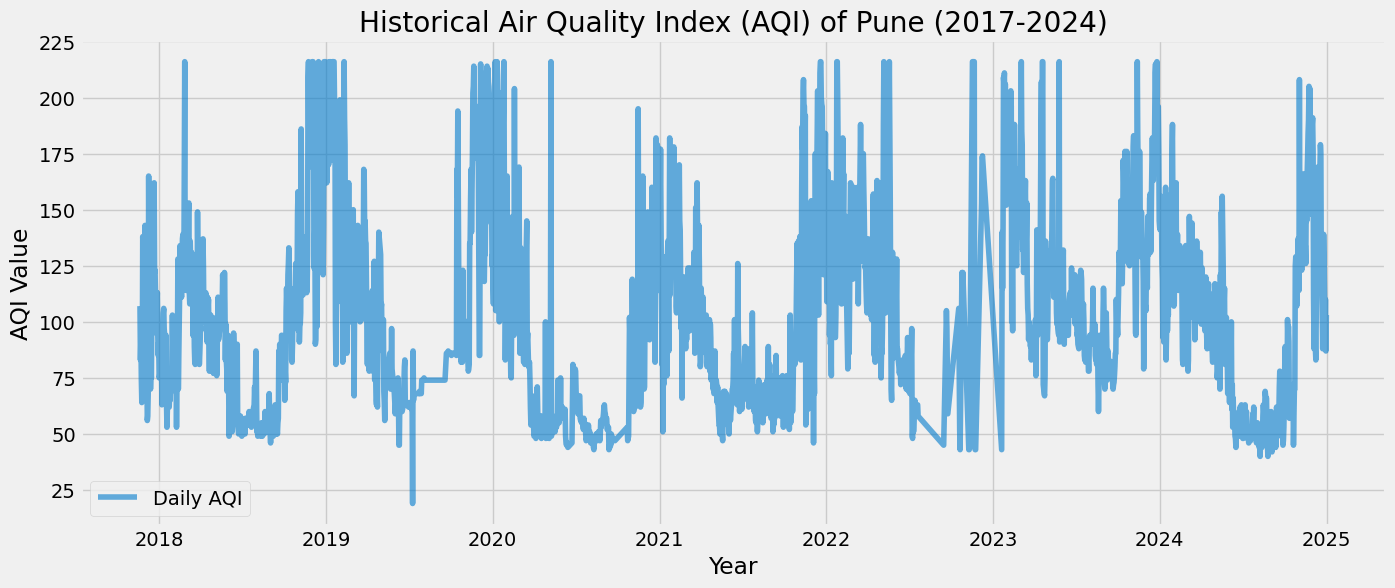

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(data['Date'], data['AQI'], label='Daily AQI', color='#007acc', alpha=0.6)
plt.title('Historical Air Quality Index (AQI) of Pune (2017-2024)')
plt.xlabel('Year')
plt.ylabel('AQI Value')
plt.legend()
plt.show()

In [25]:
# Rename columns to match Prophet requirements
prophet_df = data.rename(columns={'Date': 'ds', 'AQI': 'y'})

# Train-Test Split
# We will train on data up to the end of 2023 and test on 2024 data to validate our model
train_data = prophet_df[prophet_df['ds'] < '2024-01-01']
test_data = prophet_df[prophet_df['ds'] >= '2024-01-01']

print(f"Training Data Size: {train_data.shape[0]} days")
print(f"Testing Data Size: {test_data.shape[0]} days")

Training Data Size: 2556 days
Testing Data Size: 366 days


In [26]:
# Initialize Prophet model
# yearly_seasonality=True: To capture the annual cycle (monsoon dip, winter spike)
# weekly_seasonality=True: To capture potential weekend dips in traffic/pollution
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Fit the model on the training dataset
model.fit(train_data)
print("Model training completed.")

21:37:21 - cmdstanpy - INFO - Chain [1] start processing
21:37:21 - cmdstanpy - INFO - Chain [1] done processing


Model training completed.


In [27]:
# Create a dataframe for future dates
# We want to predict for the length of the test set (2024) plus maybe some future days
future = model.make_future_dataframe(periods=len(test_data), freq='D')

# Predict
forecast = model.predict(future)

# Display the forecast dataframe
# 'yhat' is the predicted value
# 'yhat_lower' and 'yhat_upper' are the uncertainty intervals
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
2917,2024-12-27,197.264627,158.664294,234.826842
2918,2024-12-28,195.196016,157.016450,234.549311
2919,2024-12-29,193.271947,157.810905,233.616321
2920,2024-12-30,190.264494,148.130968,226.819344
2921,2024-12-31,188.806711,154.236895,229.801518


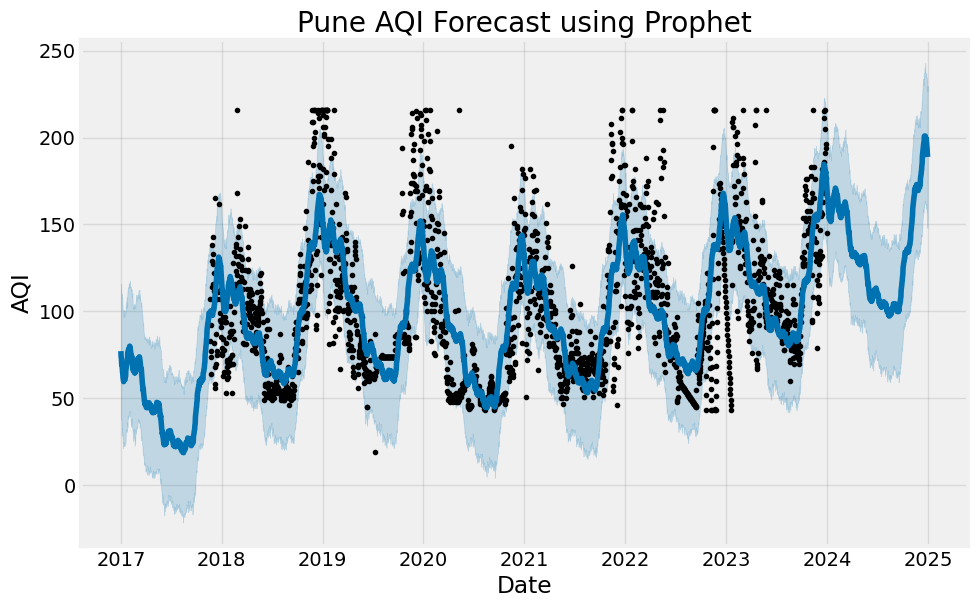

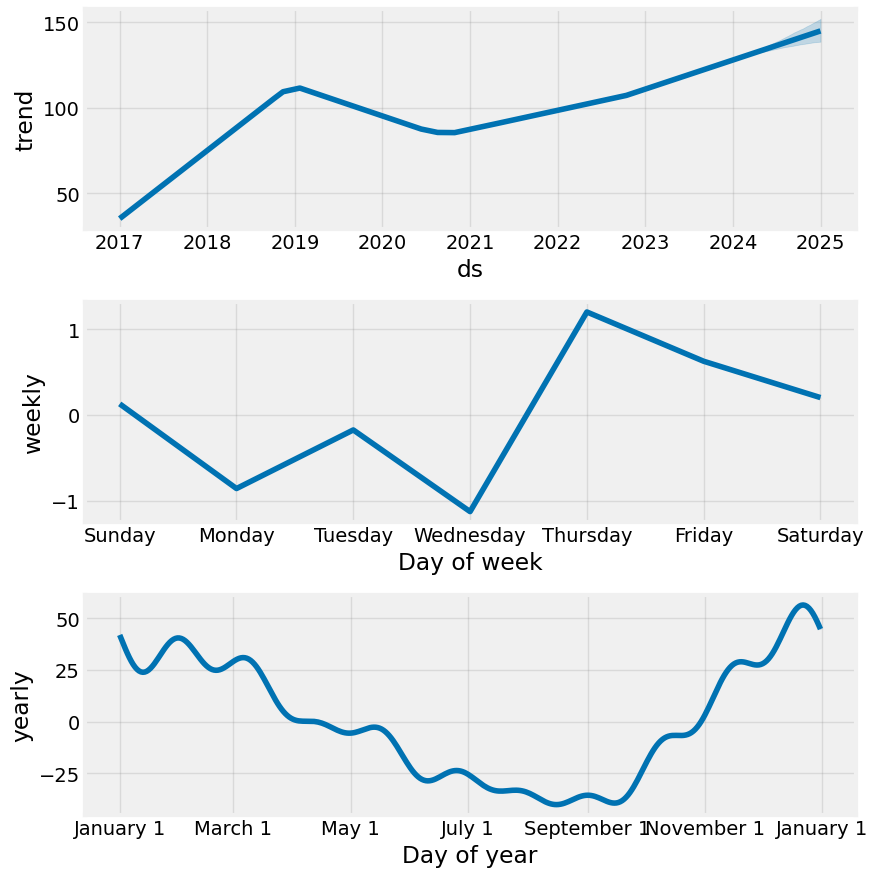

In [28]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title('Pune AQI Forecast using Prophet')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

# Plot the components (Trend, Weekly, Yearly)
fig2 = model.plot_components(forecast)
plt.show()

Model Performance on 2024 Data:
Mean Absolute Error (MAE): 41.59
Root Mean Squared Error (RMSE): 46.38


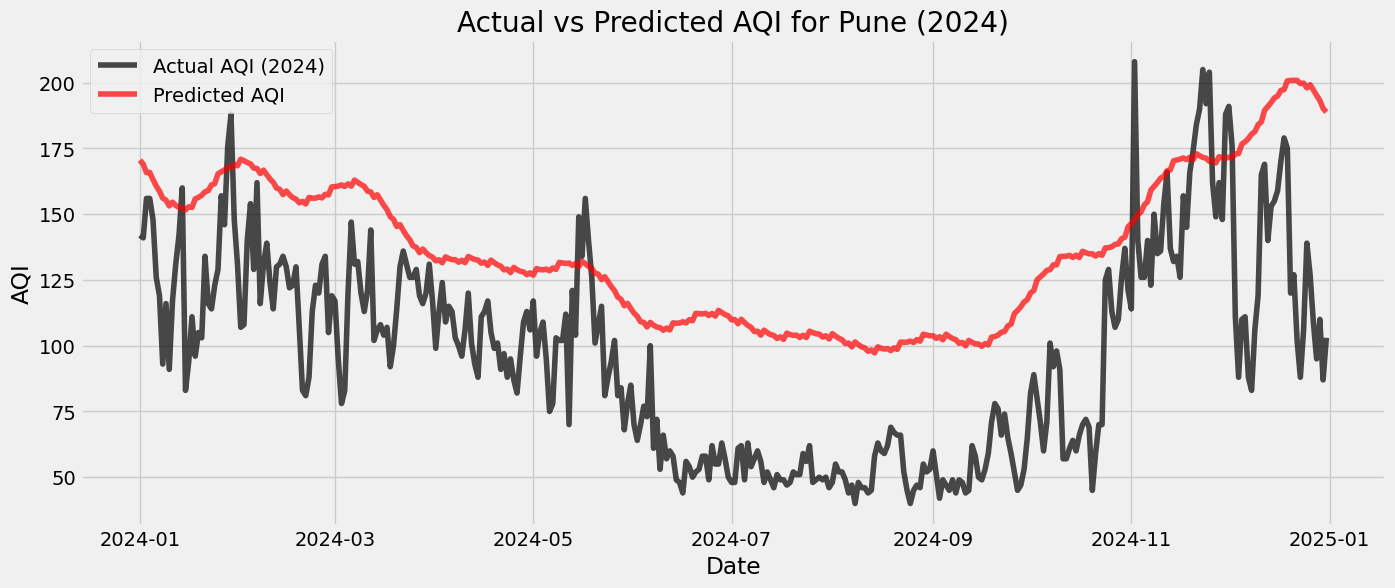

In [29]:
# Merge the forecast with the actual test data
metric_df = forecast.set_index('ds')[['yhat']].join(test_data.set_index('ds')).dropna()

# Calculate Metrics
mae = mean_absolute_error(metric_df['y'], metric_df['yhat'])
rmse = np.sqrt(mean_squared_error(metric_df['y'], metric_df['yhat']))

print("Model Performance on 2024 Data:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot Actual vs Predicted for 2024
plt.figure(figsize=(15, 6))
plt.plot(metric_df.index, metric_df['y'], label='Actual AQI (2024)', color='black', alpha=0.7)
plt.plot(metric_df.index, metric_df['yhat'], label='Predicted AQI', color='red', alpha=0.7)
plt.title('Actual vs Predicted AQI for Pune (2024)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()

In [30]:
### **Project Conclusion**
# 1. **Seasonality:** The component plots clearly show the impact of the seasons. AQI is lowest during the monsoon months (July-August) and peaks during the winter months (December-January).
# 2. **Trend:** The overall trend component helps us see if pollution is rising or falling over the years, independent of the seasons.
# 3. **Accuracy:** The RMSE value indicates the average deviation of our prediction from the actual values. This baseline model can be improved further by adding external regressors like traffic data or humidity.